Optimization Progress:   0%|          | 0/300 [00:00<?, ?pipeline/s]


Generation 1 - Current best internal CV score: 0.9488486208942355

Generation 2 - Current best internal CV score: 0.9488486208942355

Generation 3 - Current best internal CV score: 0.9488486208942355

Generation 4 - Current best internal CV score: 0.9488486208942355

Generation 5 - Current best internal CV score: 0.9490845534175338

Best pipeline: XGBClassifier(MinMaxScaler(MLPClassifier(input_matrix, alpha=0.001, learning_rate_init=0.1)), learning_rate=0.1, max_depth=10, min_child_weight=6, n_estimators=100, n_jobs=1, subsample=1.0, verbosity=0)


c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


Resultados del modelo AutoML TPOT en el conjunto de prueba:
Accuracy: 0.9465
Log Loss (pérdida logarítmica): 0.1470
AUC: 0.9353
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9730
           1       0.80      0.46      0.58       867

    accuracy                           0.95     10597
   macro avg       0.88      0.72      0.78     10597
weighted avg       0.94      0.95      0.94     10597



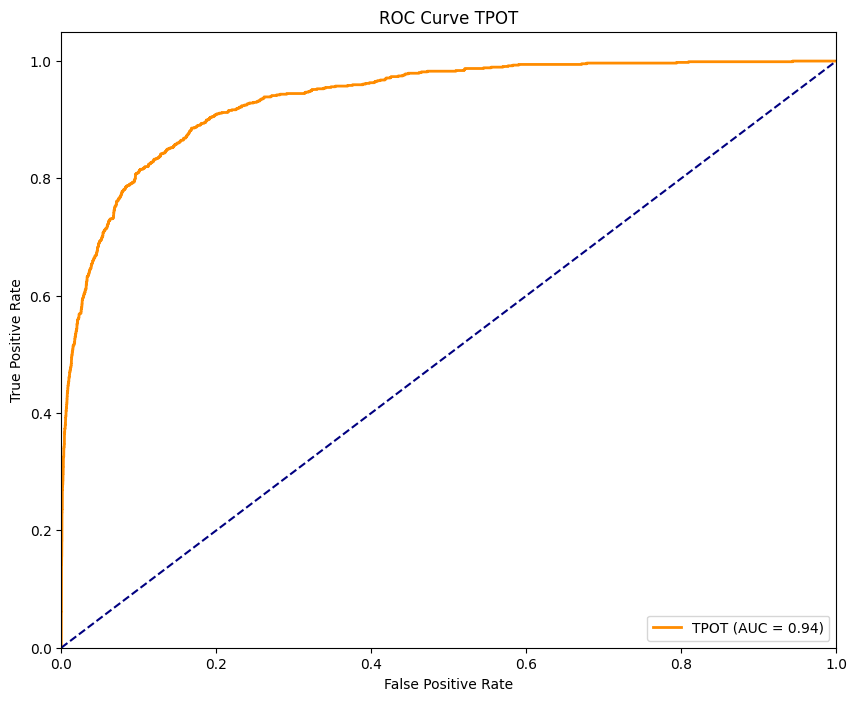

In [1]:
import pandas as pd
from tpot import TPOTClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, log_loss, roc_auc_score, classification_report
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir los datos en entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Instanciar y entrenar el modelo TPOT
tpot = TPOTClassifier(generations=5, population_size=50, verbosity=2, random_state=42)
tpot.fit(X_train, y_train)

# Predicción y evaluación en el conjunto de validación
y_pred_tpot = tpot.predict(X_val)
y_pred_proba_tpot = tpot.predict_proba(X_val)[:, 1]

# Calcular métricas de evaluación, incluyendo pérdida logarítmica
accuracy_tpot = accuracy_score(y_val, y_pred_tpot)
logloss_tpot = log_loss(y_val, y_pred_proba_tpot)
auc_tpot = roc_auc_score(y_val, y_pred_proba_tpot)

# Mostrar los resultados del modelo TPOT
print("Resultados del modelo AutoML TPOT en el conjunto de prueba:")
print(f"Accuracy: {accuracy_tpot:.4f}")
print(f"Log Loss (pérdida logarítmica): {logloss_tpot:.4f}")
print(f"AUC: {auc_tpot:.4f}")
print(classification_report(y_val, y_pred_tpot))

# Exportar el pipeline optimizado de TPOT
tpot.export('tpot_best_pipeline.py')

# Graficar la curva ROC para TPOT
fpr, tpr, _ = roc_curve(y_val, y_pred_proba_tpot)
roc_auc_tpot = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'TPOT (AUC = {roc_auc_tpot:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve TPOT')
plt.legend(loc='lower right')
plt.show()
